In [1]:
save_data = False

In [2]:
import importlib
import torch
import torch.nn.functional as F
from PIL import Image, ImageFilter
import PCA_law
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from time import sleep
from skimage.morphology import thin, skeletonize

importlib.reload(PCA_law)

from PCA_law import PCA_law, PCA_classifier


In [3]:
torch.cuda.is_available()

True

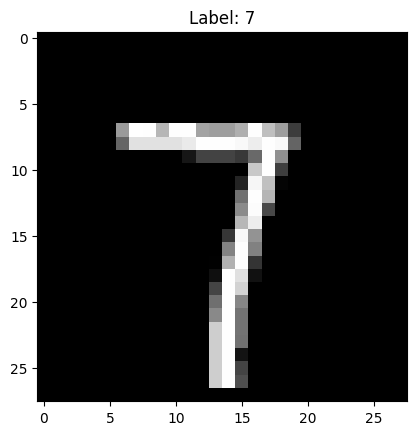

Center of mass: tensor([13.6574, 13.8645])


In [4]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.ToTensor()
mnist_train = datasets.MNIST(root='data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Example image
npic = 2512
img, label = mnist_train[npic]
img = img.squeeze() # Remove channel dimension
plt.imshow(img, cmap='gray')
plt.title(f"Label: {label}")
plt.show()

d1, d2 = img.shape
center = torch.tensor([0,0], dtype=torch.float32)
weight = torch.tensor([0,0], dtype=torch.float32)
for i in range(d1):
    for j in range(d2):
        center += torch.tensor([i, j]) * img[i, j]
        weight += img[i, j]
center/=weight
print("Center of mass:", center)


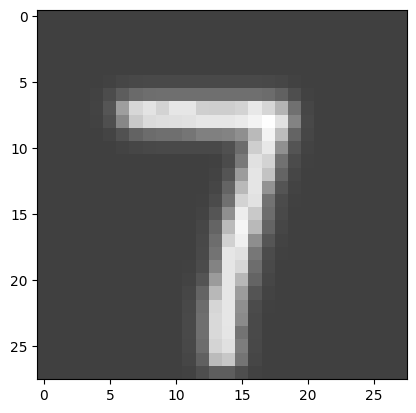

In [5]:
dim = img.shape
mask = torch.zeros(dim, dtype=torch.float32)

def gaussian(mu, sigma, dim):
    x = torch.arange(dim[0], dtype=torch.float32)
    y = torch.arange(dim[1], dtype=torch.float32)
    grid = torch.stack(torch.meshgrid(x, y, indexing='ij'), dim=-1)-mu
    r2 = (grid ** 2).sum(dim=-1)
    return torch.exp(-r2 / (2 * sigma**2))

for mu in torch.nonzero(img>0.5):
    mask += gaussian(mu,1, dim)
mask/=mask.max()
mask-=0.5
plt.imshow(img, cmap='gray', alpha=0.5)
plt.imshow(mask, cmap='gray', alpha=0.5)
plt.show()

fits: 117, does not fit 0


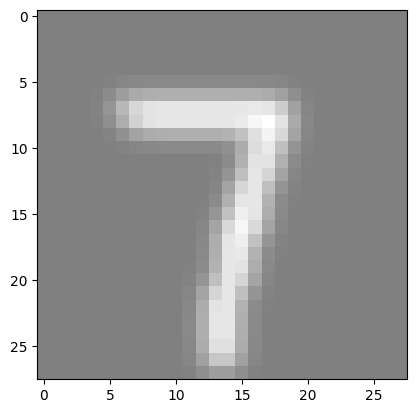

In [6]:
Xtrain = mnist_train.data.squeeze() /255
ytrain = mnist_train.targets.squeeze()
result = (Xtrain * mask).sum(dim=(1, 2))
result /= result.max()
bests = torch.nonzero(result>0.65)
nofit = bests[ytrain[bests]!=7]
are_not_fitting_characters = nofit.shape[0]
print(f'fits: {bests.shape[0]}, does not fit {nofit.shape[0]}')
if are_not_fitting_characters:
    print(f'no fit label: {ytrain[nofit[0]]}')
    plt.imshow(Xtrain[nofit[0]].squeeze(), cmap='grey', alpha=0.8)
plt.imshow(mask, cmap='gray', alpha=0.5)
plt.show()


In [21]:
# 2) Choose device/dtype once
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32   # faster on GPU; use float64 if you need extra numerical stability

Yrange = torch.unique(mnist_train.targets)

# 3) Flatten, normalize, and move EVERYTHING once
X_train = mnist_train.data.view(len(mnist_train), -1).to(device=device, dtype=dtype) / 255.0   # [60000, 784]
y_train = mnist_train.targets.to(device=device, dtype=torch.long)
Xdict = { int(y):X_train[mnist_train.targets==y] for y in Yrange}

X_test  = mnist_test.data.view(len(mnist_test), -1).to(device=device, dtype=dtype) / 255.0     # [10000, 784]
y_test  = mnist_test.targets.to(device=device, dtype=torch.long)

# 4) Import your PCA classifier (the nn.Module / buffer-based version)
# from torch_pca_classifier import PCA_classifier
# (paste the class definitions into scope if not using a module file)

clf = PCA_classifier(n_components=40, center=True, dtype=dtype)

# 5) Fit once on the whole training set (28*28=784 so eigendecomp is tiny)
with torch.inference_mode():  # no gradients anywhere
    clf.fit(X_train, y_train)

# 6) Predict on the whole test set at once (fastest)
with torch.inference_mode():
    y_pred_test = clf.predict(X_test, return_numpy=False)   # tensor on device
    y_pred_train = clf.predict(X_train, return_numpy=False)   # tensor on device

# 7) Accuracy
acc_test = (y_pred_test == y_test).float().mean().item()
acc_train = (y_pred_train == y_train).float().mean().item()
print(f"Train accuracy: {acc_train*100:.2f}%")
print(f"Test accuracy: {acc_test*100:.2f}%")


Train accuracy: 95.73%
Test accuracy: 95.62%


In [23]:
n_components = 35
npart = 5
ndata = Xdict[0].shape[0]//npart
print('len(ndata)=', ndata )
pclaw = []
for n in range(npart):
    pclaw.append(PCA_law(n_components= n_components))
    pclaw[-1].fit(Xdict[0][n:n+ndata])
    print(pclaw[-1].chi2(Xdict[0][n:n+ndata]).mean())

len(ndata)= 1184
tensor(0.4173, device='cuda:0')
tensor(0.4154, device='cuda:0')
tensor(0.4280, device='cuda:0')
tensor(1.1108, device='cuda:0')
tensor(0.4111, device='cuda:0')


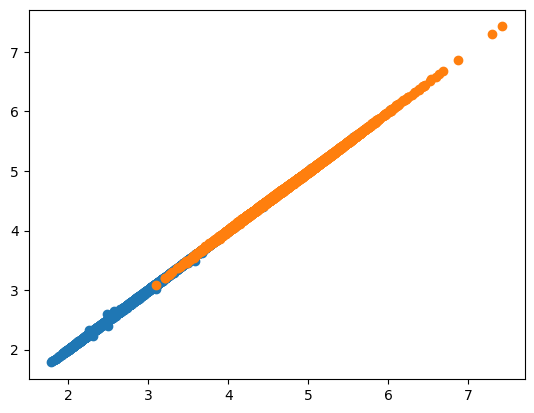

In [47]:
ch0 = torch.stack((pclaw[0].classify(Xdict[0]), pclaw[4].classify(Xdict[0])), dim=0).cpu()
ch1 = torch.stack((pclaw[0].classify(Xdict[1]), pclaw[4].classify(Xdict[1])), dim=0).cpu()
plt.plot(*ch0,'o')
plt.plot(*ch1,'o')

(array([3.000e+00, 5.000e+00, 1.400e+01, 3.700e+01, 6.400e+01, 1.400e+02,
        2.350e+02, 4.420e+02, 6.500e+02, 8.480e+02, 1.002e+03, 8.660e+02,
        7.240e+02, 5.510e+02, 4.200e+02, 2.900e+02, 1.670e+02, 1.210e+02,
        7.100e+01, 3.700e+01, 2.000e+01, 1.500e+01, 6.000e+00, 8.000e+00,
        3.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 2.000e+00]),
 array([3.09113169, 3.2354579 , 3.37978411, 3.52411032, 3.66843677,
        3.81276298, 3.95708919, 4.10141563, 4.24574184, 4.39006805,
        4.53439426, 4.67872047, 4.82304668, 4.96737289, 5.1116991 ,
        5.25602531, 5.40035152, 5.54467773, 5.68900394, 5.83333063,
        5.97765684, 6.12198305, 6.26630926, 6.41063547, 6.55496168,
        6.69928837, 6.84361458, 6.98794079, 7.132267  , 7.27659321,
        7.42091942]),
 <BarContainer object of 30 artists>)

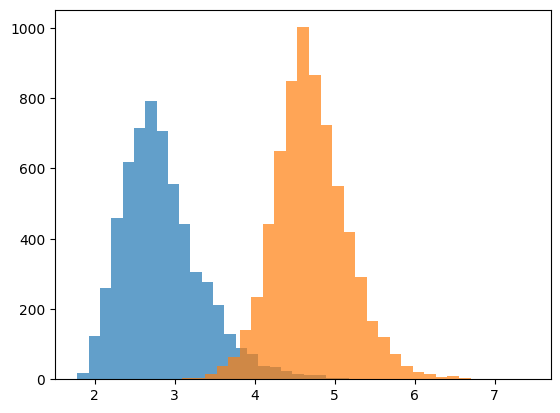

In [32]:
plt.hist(pclaw[0].classify(Xdict[0]).cpu(),alpha=0.7, bins=30)
plt.hist(pclaw[0].classify(Xdict[1]).cpu(),alpha=0.7, bins=30)

In [9]:
Xdict[0].shape

torch.Size([5923, 28, 28])

In [ ]:
STOP HERE

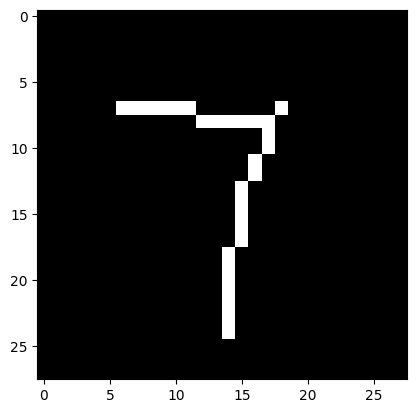

In [ ]:
skel = skeletonize(img.squeeze().cpu().numpy().astype(bool))  # or thin(...)
plt.imshow(skel, cmap='gray')

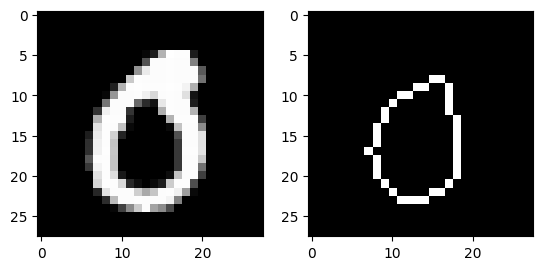

In [ ]:
img = Xdict[0][200]
skel = skeletonize(img.squeeze().cpu().numpy().astype(bool))  # or thin(...)
fig, ax = plt.subplots(1,2)
ax[1].imshow(skel, cmap='gray')
ax[0].imshow(img, cmap='gray')

((4, 23), (7, 22))
torch.Size([1, 1, 8, 8])


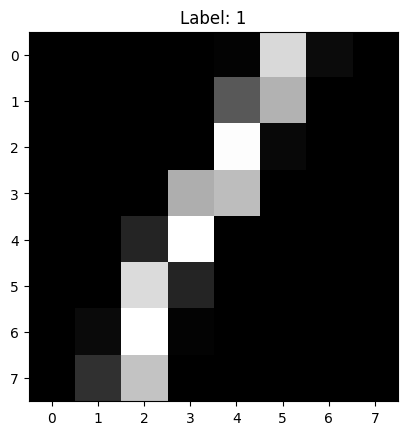

In [ ]:
label=1
img = Xdict[label][210]
threshold= 0.9
bb = torch.tensor([ [i,j] for i in range(d1) for j in range(d2) if img[i,j]>threshold], dtype=int)
bbox = ((bb[:,0].min().item(), bb[:,0].max().item()), (bb[:,1].min().item(), bb[:,1].max().item()))
print(bbox)
dx = bbox[0][1]-bbox[0][0]+1
dy = bbox[1][1]-bbox[1][0]+1
img1 = F.pad(img[ bbox[0][0]:bbox[0][0]+dx, bbox[1][0]:bbox[1][0]+dy], (5,5,0,0), mode='constant', value=0).unsqueeze(0).unsqueeze(0).float()
resized = F.interpolate(img1, size=(8, 8), mode='bilinear', align_corners=False)
print(resized.shape)
plt.imshow(resized.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()


In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms

# --- params you can tweak ---
THRESH = 0.7          # grayscale threshold for bbox
TARGET_SIZE = 25       # final H=W size

def bbox_from_threshold(img01: torch.Tensor, thr: float = 0.9):
    """
    img01: (1, H, W) float tensor in [0,1]
    returns: (top, bottom, left, right) inclusive indices for cropping
    """
    # mask of "bright" pixels
    mask = (img01 > thr)[0]  # -> (H, W)

    # fallback if nothing above threshold (rare but safe)
    if not mask.any():
        # try a softer threshold
        mask = (img01 > 0.5)[0]
    if not mask.any():
        # as a last resort: keep the whole image
        H, W = img01.shape[-2:]
        return 0, H - 1, 0, W - 1

    ys = torch.where(mask.any(dim=1))[0]
    xs = torch.where(mask.any(dim=0))[0]
    top, bottom = int(ys[0]), int(ys[-1])
    left, right = int(xs[0]), int(xs[-1])
    return top, bottom, left, right

def pad_to_square(img: torch.Tensor):
    """
    img: (1, h, w)
    returns: (1, s, s) centered with zero padding
    """
    _, h, w = img.shape
    s = max(h, w)
    pad_top    = (s - h) // 2
    pad_bottom = s - h - pad_top
    pad_left   = (s - w) // 2
    pad_right  = s - w - pad_left
    # F.pad order: (left, right, top, bottom)
    return F.pad(img, (pad_left, pad_right, pad_top, pad_bottom), mode="constant", value=0.0)

def resize_to(img: torch.Tensor, size: int, mode: str = "bilinear"):
    """
    img: (1, s, s) -> (1, size, size)
    """
    img = img.unsqueeze(0)            # (N=1, C=1, H, W)
    out = F.interpolate(img, size=(size, size), mode=mode, align_corners=False if mode!="nearest" else None)
    return out.squeeze(0)             # back to (1, size, size)

def preprocess_mnist(threshold=THRESH, target_size=TARGET_SIZE, interp_mode="bilinear", train=True):
    """
    Returns:
      X: (N, 1, target_size, target_size) float32 in [0,1]
      y: (N,) int64 labels
      ds: TensorDataset(X, y)
    """
    mnist = datasets.MNIST(root="data", train=train, download=True, transform=transforms.ToTensor())
    N = len(mnist)
    examples = []
    labels = []

    for i in range(N):
        img, label = mnist[i]          # img: (1, 28, 28) float in [0,1]
        img = img.to(dtype=torch.float32)

        # 1) tight bbox where img > threshold
        t, b, l, r = bbox_from_threshold(img, thr=threshold)
        cropped = img[:, t:b+1, l:r+1]  # (1, h, w)

        # 2) pad to square (center)
        squared = pad_to_square(cropped)  # (1, s, s)

        # 3) resize to target size
        resized = resize_to(squared, target_size, mode=interp_mode)  # (1, S, S)

        examples.append(resized)
        labels.append(label)

    X = torch.stack(examples, dim=0)          # (N, 1, S, S)
    y = torch.tensor(labels, dtype=torch.long)
    ds = TensorDataset(X, y)
    return X, y, ds


# preprocess train set
X_train, y_train, ds_train = preprocess_mnist(threshold=THRESH, target_size=TARGET_SIZE, interp_mode="bilinear", train=True)
X_test , y_test , ds_test  = preprocess_mnist(threshold=THRESH, target_size=TARGET_SIZE, interp_mode="bilinear", train=False)

# example loader (optional)
#BATCH_SIZE = 128      # example for a loader
#train_loader = DataLoader(ds_train, batch_size=128, shuffle=True)

print("Processed shapes:", X_train.shape, y_train.shape)
# e.g. torch.Size([60000, 1, 8, 8]) torch.Size([60000])


Processed shapes: torch.Size([60000, 1, 25, 25]) torch.Size([60000])


tensor(5)

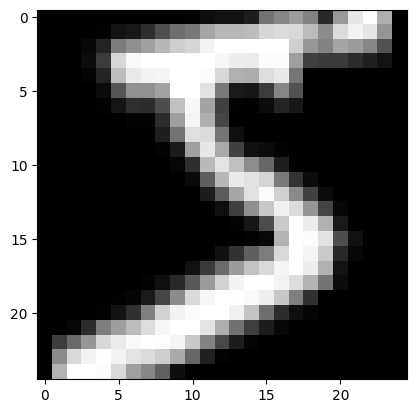

In [ ]:
plt.imshow(X_train[0].squeeze(), cmap='grey')
y_train[0]

In [ ]:
# 2) Choose device/dtype once
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32   # faster on GPU; use float64 if you need extra numerical stability
n_components = 25


clf = PCA_classifier(n_components=n_components, center=True, dtype=dtype)

# 3) Flatten, normalize, and move EVERYTHING once
XM_train = X_train.view(len(X_train), -1).to(device=device, dtype=dtype) / 255.0   # [60000, 784]
yM_train = y_train.to(device=device, dtype=torch.long)

XM_test = X_test.view(len(X_test), -1).to(device=device, dtype=dtype) / 255.0   # [60000, 784]
yM_test = y_test.to(device=device, dtype=torch.long)

# 5) Fit once on the whole training set (28*28=784 so eigendecomp is tiny)
with torch.inference_mode():  # no gradients anywhere
    clf.fit(XM_train, yM_train)

# 6) Predict on the whole test set at once (fastest)
with torch.inference_mode():
    y_pred_test = clf.predict(XM_test, return_numpy=False)   # tensor on device
    y_pred_train = clf.predict(XM_train, return_numpy=False)   # tensor on device

# 7) Accuracy
acc_test = (y_pred_test == yM_test).float().mean().item()
acc_train = (y_pred_train == yM_train).float().mean().item()
print(f"Train accuracy: {acc_train*100:.2f}%")
print(f"Test accuracy: {acc_test*100:.2f}%")

Train accuracy: 94.83%
Test accuracy: 95.18%


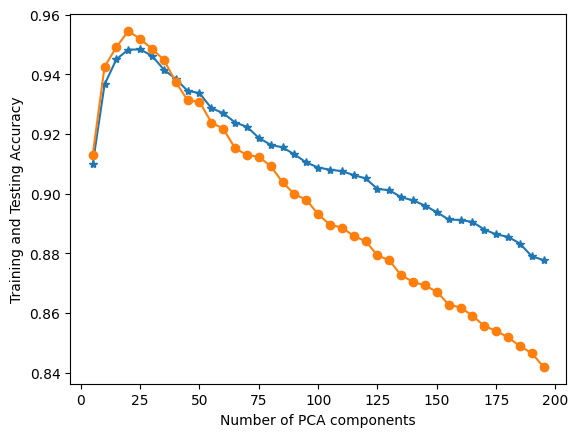

In [ ]:
results = []
R = range(1, 200, 3)
Rlen = len(R)
for i,n_components in enumerate(range(5, 200, 5)):
    print(f'{n_components:4d} -- {i+1:3d}/{Rlen} -> {100*(i+1)/Rlen:.1f}%', end='\r')
    clf = PCA_classifier(n_components=n_components, center=True, dtype=dtype)

    # 5) Fit once on the whole training set (28*28=784 so eigendecomp is tiny)
    with torch.inference_mode():  # no gradients anywhere
        clf.fit(XM_train, yM_train)

    # 6) Predict on the whole test set at once (fastest)
    with torch.inference_mode():
        y_pred_test = clf.predict(XM_test, return_numpy=False)   # tensor on device
        y_pred_train = clf.predict(XM_train, return_numpy=False)   # tensor on device

    # 7) Accuracy
    acc_train = (y_pred_train == yM_train).float().mean().item()
    acc_test = (y_pred_test == yM_test).float().mean().item()
    results.append((n_components, acc_train, acc_test))
results = np.array(results)
plt.plot(results[:,0], results[:,1], "*-")
plt.plot(results[:,0], results[:,2], "o-")
plt.xlabel("Number of PCA components")
plt.ylabel("Training and Testing Accuracy")
plt.show()


In [ ]:
# 2) Choose device/dtype once
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32   # faster on GPU; use float64 if you need extra numerical stability

# 3) Flatten, normalize, and move EVERYTHING once
X_train = mnist_train.data.view(len(mnist_train), -1).to(device=device, dtype=dtype) / 255.0   # [60000, 784]
y_train = mnist_train.targets.to(device=device, dtype=torch.long)

X_test  = mnist_test.data.view(len(mnist_test), -1).to(device=device, dtype=dtype) / 255.0     # [10000, 784]
y_test  = mnist_test.targets.to(device=device, dtype=torch.long)

# 4) Import your PCA classifier (the nn.Module / buffer-based version)
# from torch_pca_classifier import PCA_classifier
# (paste the class definitions into scope if not using a module file)

clf = PCA_classifier(n_components=40, center=True, dtype=dtype)

# 5) Fit once on the whole training set (28*28=784 so eigendecomp is tiny)
with torch.inference_mode():  # no gradients anywhere
    clf.fit(X_train, y_train)

# 6) Predict on the whole test set at once (fastest)
with torch.inference_mode():
    y_pred_test = clf.predict(X_test, return_numpy=False)   # tensor on device
    y_pred_train = clf.predict(X_train, return_numpy=False)   # tensor on device

# 7) Accuracy
acc_test = (y_pred_test == y_test).float().mean().item()
acc_train = (y_pred_train == y_train).float().mean().item()
print(f"Train accuracy: {acc_train*100:.2f}%")
print(f"Test accuracy: {acc_test*100:.2f}%")


Train accuracy: 95.73%
Test accuracy: 95.62%


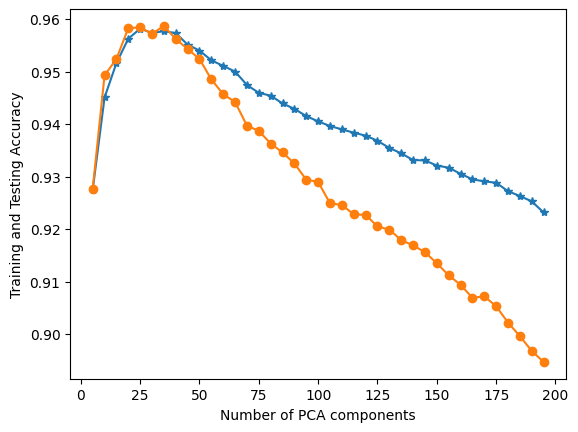

In [ ]:
results = []
R = range(5, 200, 5)
Rlen = len(R)
for i,n_components in enumerate(range(5, 200, 5)):
    print(f'{n_components:4d} -- {i+1:3d}/{Rlen} -> {100*(i+1)/Rlen:.1f}%', end='\r')
    clf = PCA_classifier(n_components=n_components, center=True, dtype=dtype)

    # 5) Fit once on the whole training set (28*28=784 so eigendecomp is tiny)
    with torch.inference_mode():  # no gradients anywhere
        clf.fit(X_train, y_train)

    # 6) Predict on the whole test set at once (fastest)
    with torch.inference_mode():
        y_pred_test = clf.predict(X_test, return_numpy=False)   # tensor on device
        y_pred_train = clf.predict(X_train, return_numpy=False)   # tensor on device

    # 7) Accuracy
    acc_train = (y_pred_train == y_train).float().mean().item()
    acc_test = (y_pred_test == y_test).float().mean().item()
    results.append((n_components, acc_train, acc_test))
results = np.array(results)
plt.plot(results[:,0], results[:,1], "*-")
plt.plot(results[:,0], results[:,2], "o-")
plt.xlabel("Number of PCA components")
plt.ylabel("Training and Testing Accuracy")
plt.show()


In [ ]:
mnist_train = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
X_train = mnist_train.data / 255.0
y_train = mnist_train.targets
mnist_test = datasets.MNIST(root="data", train=False, download=True, transform=transforms.ToTensor())
X_test = mnist_test.data / 255.0
y_test = mnist_test.targets


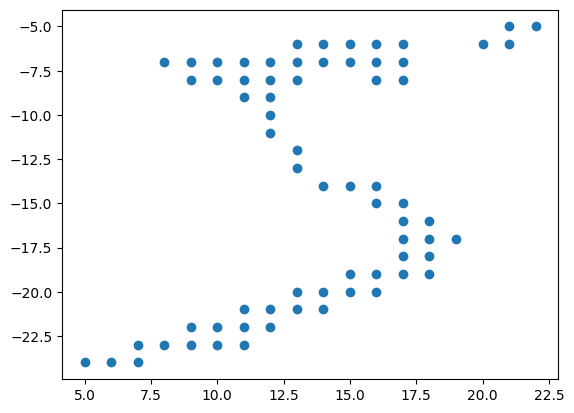

In [ ]:
p = torch.nonzero(X_train[0]>0.9).float()
plt.plot(p.T[1], -p.T[0],'o')

In [ ]:
p.shape

torch.Size([68, 2])

In [ ]:
results = []
for phi in np.linspace(0, 2*np.pi, 11):
    n = torch.tensor([np.cos(phi), np.sin(phi)], dtype=torch.float32)
    results.append(p@n)

(array([ 4.,  7.,  9.,  7.,  4.,  2.,  2.,  4., 15., 14.]),
 array([10.36540031, 11.92400646, 13.48261166, 15.0412178 , 16.599823  ,
        18.15842819, 19.71703529, 21.27564049, 22.83424759, 24.39285278,
        25.95145798]),
 <BarContainer object of 10 artists>)

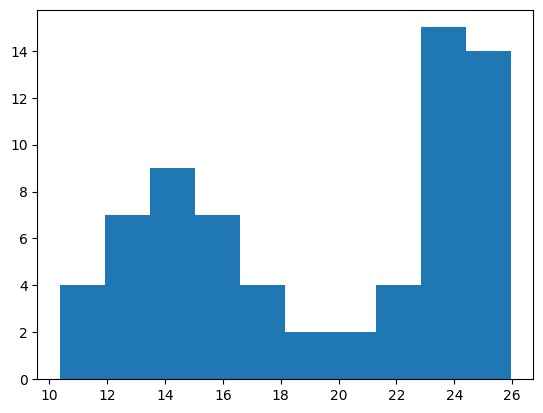

In [ ]:
plt.hist(results[1])

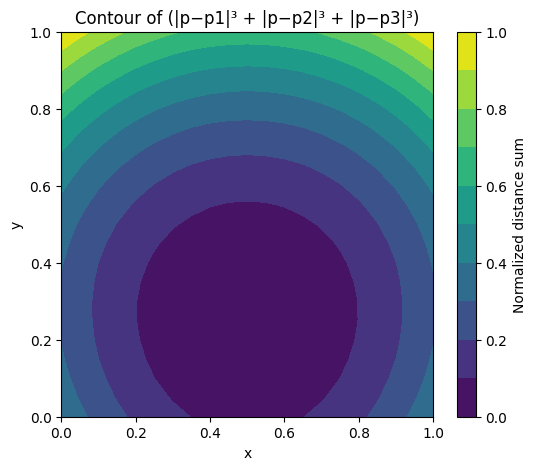

In [ ]:
p1 = np.array([0,0])
p2 = np.array([1,0])
p3 = np.array([0.5, 0.8])
dist = []
for x in np.linspace(0,1,21):
    for y in np.linspace(0,1,21):
        p = np.array([x,y])
        d1 = np.linalg.norm(p1-p)**3
        d2 = np.linalg.norm(p2-p)**3
        d3 = np.linalg.norm(p3-p)**3
        dist.append( [d1+d2+d3, x,y])
dist = np.array(dist).T
dist[0] = (dist[0]-dist[0].min())/(dist[0].max()-dist[0].min())
# --- reshape into 2D grids ---
n = 21
Z = dist[0].reshape(n, n)
X = dist[1].reshape(n, n)
Y = dist[2].reshape(n, n)

# --- make a contour plot ---
plt.figure(figsize=(6,5))
cont = plt.contourf(X, Y, Z, levels=10, cmap='viridis')
plt.colorbar(cont, label='Normalized distance sum')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Contour of (|p−p1|³ + |p−p2|³ + |p−p3|³)')
plt.show()


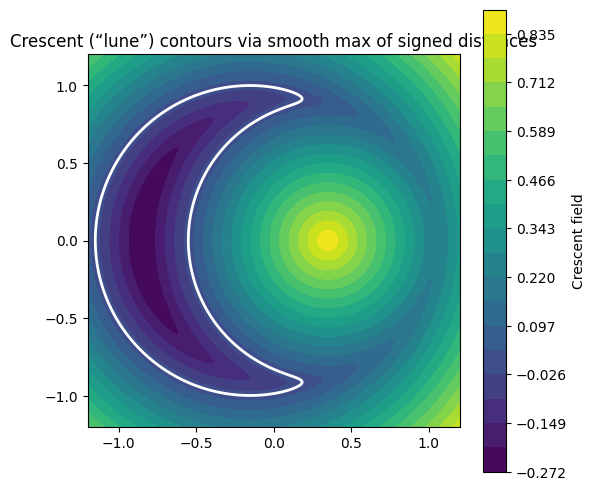

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Grid
n = 400
x = np.linspace(-1.2, 1.2, n)
y = np.linspace(-1.2, 1.2, n)
X, Y = np.meshgrid(x, y)

# Two circles: inside Circle1 AND outside Circle2 => crescent (lune)
c1 = np.array([-0.15, 0.0]); R1 = 1.0   # big circle
c2 = np.array([+0.35, 0.0]); R2 = 0.9   # slightly smaller, shifted

# Signed distances (positive outside the circle)
s1 = np.sqrt((X - c1[0])**2 + (Y - c1[1])**2) - R1        # outside circle1 => s1>0
s2 = R2 - np.sqrt((X - c2[0])**2 + (Y - c2[1])**2)        # inside circle2 => s2>0

# Smooth "max": smax(a,b) ~ max(a,b) but differentiable (beta controls sharpness)
beta = 25.0
F = (1/beta)*np.log(np.exp(beta*s1) + np.exp(beta*s2))

# Plot crescent-like contours (0 is the exact boundary of the lune)
plt.figure(figsize=(6,6))
cs = plt.contourf(X, Y, F, levels=np.linspace(F.min(), F.max(), 20), cmap='viridis')
plt.contour(X, Y, F, levels=[0.0], colors='white', linewidths=2)  # boundary
plt.colorbar(cs, label='Crescent field')
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Crescent (“lune”) contours via smooth max of signed distances')
plt.show()


In [ ]:
X0 = X_train[y_train==0]
X1 = X_train[y_train!=0]

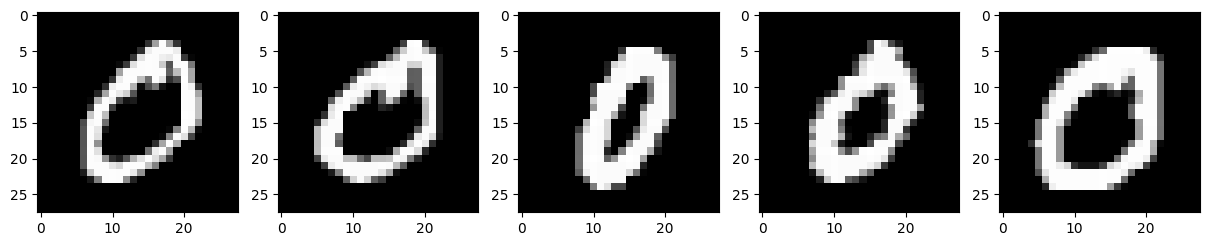

In [ ]:
ncols=5
fig, ax = plt.subplots(1, ncols, figsize=(3*ncols, 3))
for i in range(ncols):
    ax[i].imshow(X0[i], cmap='gray')

In [ ]:
n_components = 35
npart = 5
ndata = X0.shape[0]//npart
print('len(ndata)=', ndata )
pclaw = []
for n in range(npart):
    pclaw.append(PCA_law(n_components= n_components))
    pclaw[-1].fit(X0[n:n+ndata].reshape(-1,28*28))
    print(pclaw[-1].chi2(X0[n:n+ndata].reshape(-1,28*28)).mean())

len(ndata)= 1184
0.40878433
0.40878436
0.4087844
0.4087844
0.4087843


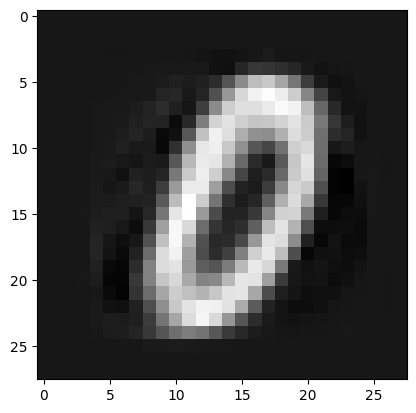

In [ ]:
pp0 = pclaw[-1].compress(X0[2].reshape(-1,28*28))
xrecon = pclaw[-1].reconstruct(pp0).reshape(28,28)
plt.imshow(xrecon, cmap='gray')

In [ ]:
[np.mean(pp.chi2(X0.reshape(-1,28*28), ep=1e-30)) for pp in pclaw]  

[np.float32(8.178415e+26),
 np.float32(8.178415e+26),
 np.float32(8.178415e+26),
 np.float32(8.178415e+26),
 np.float32(8.178415e+26)]

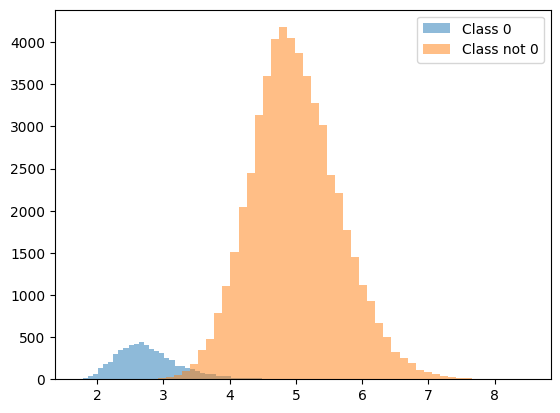

In [ ]:
u = pclaw.classify(X0.reshape(-1,28*28))
v = pclaw.classify(X1.reshape(-1,28*28))
plt.hist(u, bins=50, alpha=0.5, label='Class 0')
plt.hist(v, bins=50, alpha=0.5, label='Class not 0')
plt.legend()
plt.show()